In [1]:
TRAIN_PATH = "train_set_selected.csv"
TEST_PATH = "test_set_selected.csv"
TARGET_COL = None
RANDOM_STATE = 42
N_FOLDS = 5

# GridSearchCV parameter grid
PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

# Path output
FINAL_MODEL_PATH = "model.pkl"
FEATURE_ORDER_PATH = "feature_order.json"
SELECTED_FEATURES_PATH = "selected_features.json"
SCALER_PATH = None

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import time
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    learning_curve,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
print(f"Training set dimuat: {train_df.shape[0]} baris, {train_df.shape[1]} kolom")

if TARGET_COL is None:
    candidate_names = ["label", "Label", "class", "Class", "type", "Type",
                        "target", "Target", "phishing", "Phishing", "y", "Result", "result"]
    found = [c for c in candidate_names if c in train_df.columns]
    if found:
        TARGET_COL = found[0]
        print(f"Kolom target terdeteksi otomatis: '{TARGET_COL}'")

assert TARGET_COL is not None and TARGET_COL in train_df.columns, \
    "TARGET_COL belum valid. Isi manual di cell konfigurasi."

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

print(f"Jumlah fitur: {X_train.shape[1]}")
print(f"Distribusi kelas:\n{y_train.value_counts(normalize=True).round(4)}")

Training set dimuat: 41120 baris, 34 kolom
Kolom target terdeteksi otomatis: 'phishing'
Jumlah fitur: 33
Distribusi kelas:
phishing
0.0    0.6509
1.0    0.3491
Name: proportion, dtype: float64


In [4]:
print("Parameter grid yang akan di-search:")
for param, values in PARAM_GRID.items():
    print(f"  {param}: {values}")

total_combinations = 1
for v in PARAM_GRID.values():
    total_combinations *= len(v)
print(f"\nTotal kombinasi: {total_combinations}")
print(f"Total fit (kombinasi x {N_FOLDS} folds): {total_combinations * N_FOLDS}")

Parameter grid yang akan di-search:
  n_estimators: [100, 200, 300]
  max_depth: [None, 10, 20, 30]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']

Total kombinasi: 216
Total fit (kombinasi x 5 folds): 1080


In [5]:
cv_inner = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=PARAM_GRID,
    cv=cv_inner,
    scoring=["f1", "accuracy", "precision", "recall", "roc_auc"],
    refit="f1",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

start = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [6]:
# Best Result

for metric in ["f1", "accuracy", "precision", "recall", "roc_auc"]:
    mean_score = grid_search.cv_results_[f"mean_test_{metric}"][grid_search.best_index_]
    std_score = grid_search.cv_results_[f"std_test_{metric}"][grid_search.best_index_]
    print(f"  CV {metric.upper()}: {mean_score:.4f} +/- {std_score:.4f}")

  CV F1: 0.9137 +/- 0.0030
  CV ACCURACY: 0.9397 +/- 0.0021
  CV PRECISION: 0.9125 +/- 0.0037
  CV RECALL: 0.9149 +/- 0.0033
  CV ROC_AUC: 0.9794 +/- 0.0010


In [7]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)

summary_cols = [
    "param_n_estimators", "param_max_depth",
    "param_min_samples_split", "param_min_samples_leaf", "param_max_features",
    "mean_test_f1", "std_test_f1",
    "mean_test_accuracy", "mean_test_precision",
    "mean_test_recall", "mean_test_roc_auc",
    "mean_train_f1", "std_train_f1",
]

display_df = cv_results_df[summary_cols].copy()
display_df.columns = [
    "n_estimators", "max_depth",
    "min_samples_split", "min_samples_leaf", "max_features",
    "CV F1", "CV F1 Std",
    "CV Acc", "CV Prec",
    "CV Rec", "CV AUC",
    "Train F1", "Train F1 Std",
]

display_df = display_df.sort_values("CV F1", ascending=False).round(4)
print("Top 10 kombinasi parameter berdasarkan CV F1:")
display(display_df.head(10))

Top 10 kombinasi parameter berdasarkan CV F1:


,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,CV F1,CV F1 Std,CV Acc,CV Prec,CV Rec,CV AUC,Train F1,Train F1 Std
3,100,None,5,1,sqrt,0.9137,0.0030,0.9397,0.9125,0.9149,0.9794,0.9633,0.0002
30,100,None,5,1,log2,0.9137,0.0030,0.9397,0.9125,0.9149,0.9794,0.9633,0.0002
31,200,None,5,1,log2,0.9136,0.0034,0.9395,0.9118,0.9154,0.9797,0.9637,0.0004
4,200,None,5,1,sqrt,0.9136,0.0034,0.9395,0.9118,0.9154,0.9797,0.9637,0.0004
165,100,30,5,1,sqrt,0.9135,0.0024,0.9395,0.9124,0.9147,0.9793,0.9633,0.0005
192,100,30,5,1,log2,0.9135,0.0024,0.9395,0.9124,0.9147,0.9793,0.9633,0.0005
194,300,30,5,1,log2,0.9132,0.0028,0.9393,0.9114,0.9152,0.9799,0.9637,0.0004
167,300,30,5,1,sqrt,0.9132,0.0028,0.9393,0.9114,0.9152,0.9799,0.9637,0.0004
5,300,None,5,1,sqrt,0.9132,0.0028,0.9393,0.9111,0.9153,0.9799,0.9637,0.0004
32,300,None,5,1,log2,0.9132,0.0028,0.9393,0.9111,0.9153,0.9799,0.9637,0.0004


# **Final Model**

In [8]:
best_params = grid_search.best_params_
print(f"Parameter terbaik: {best_params}")

final_model = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
final_model.fit(X_train, y_train)

train_score = final_model.score(X_train, y_train)
print(f"\nFinal model berhasil dilatih.")
print(f"Training accuracy (referensi saja): {train_score:.4f}")
print(f"Jumlah trees (n_estimators): {final_model.n_estimators}")

Parameter terbaik: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Final model berhasil dilatih.
Training accuracy (referensi saja): 0.9739
Jumlah trees (n_estimators): 100


# **Final Evaluation**

In [9]:
test_df = pd.read_csv(TEST_PATH)
print(f"Test set dimuat: {test_df.shape[0]} baris, {test_df.shape[1]} kolom")

assert TARGET_COL in test_df.columns, f"Kolom target '{TARGET_COL}' tidak ditemukan di test set"

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

# Pastikan kolom fitur sama dengan training set
assert list(X_test.columns) == list(X_train.columns), \
    "Kolom fitur test set tidak sama dengan training set! Periksa kembali."

print(f"Distribusi kelas test set:\n{y_test.value_counts(normalize=True).round(4)}")

Test set dimuat: 17442 baris, 34 kolom
Distribusi kelas test set:
phishing
0    0.6503
1    0.3497
Name: proportion, dtype: float64


In [11]:
# Prediksi
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("FINAL EVALUATION — TEST SET")
print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

FINAL EVALUATION — TEST SET

Accuracy : 0.9516
Precision: 0.9312
Recall   : 0.9302
F1 Score : 0.9307
ROC AUC  : 0.9876


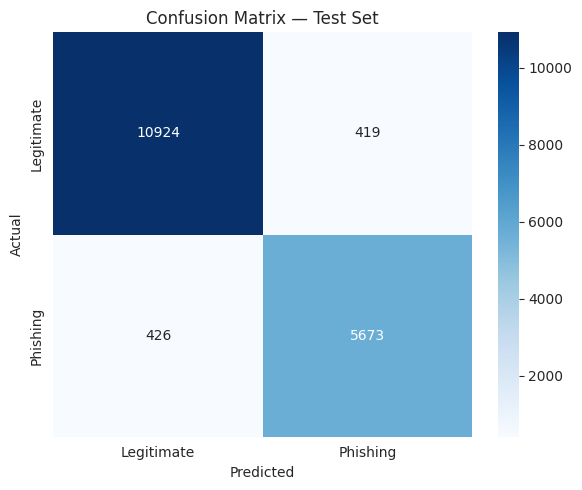

True Negatives : 10924
False Positives: 419
False Negatives: 426
True Positives : 5673


In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitimate", "Phishing"],
            yticklabels=["Legitimate", "Phishing"],
            ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

In [13]:
print("Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["Legitimate", "Phishing"]))

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96     11343
    Phishing       0.93      0.93      0.93      6099

    accuracy                           0.95     17442
   macro avg       0.95      0.95      0.95     17442
weighted avg       0.95      0.95      0.95     17442



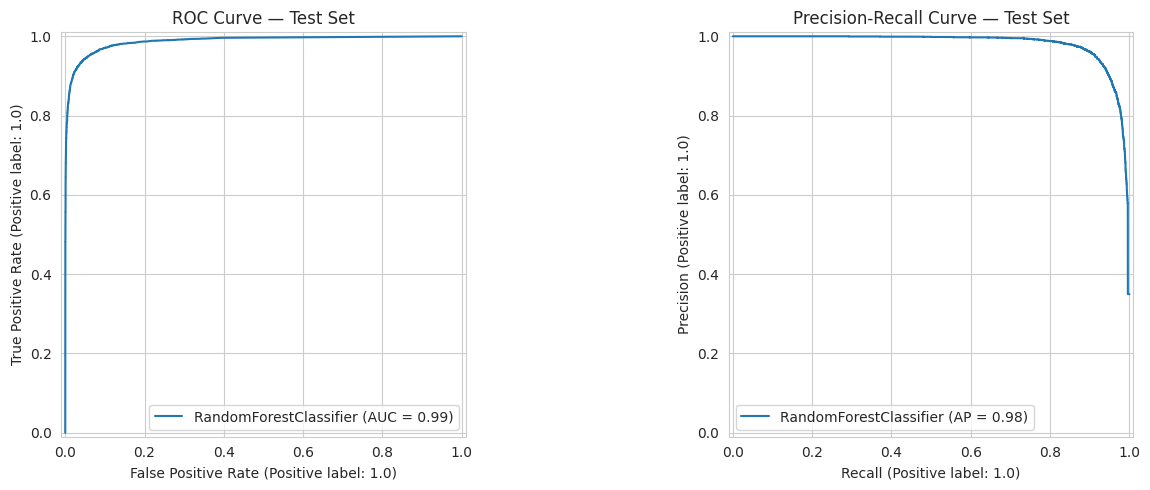

In [14]:
# Precision-Recall Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=ax1)
ax1.set_title("ROC Curve — Test Set")

PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test, ax=ax2)
ax2.set_title("Precision-Recall Curve — Test Set")

plt.tight_layout()
plt.show()

In [15]:
# Cross-validation pada final model
cv_final = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results_final = cross_validate(
    final_model, X_train, y_train,
    cv=cv_final,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    return_train_score=True,
    n_jobs=-1,
)

print(f"Cross-Validation ({N_FOLDS}-Fold) — Final Model:\n")
comparison = []
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    train_mean = cv_results_final[f"train_{metric}"].mean()
    cv_mean = cv_results_final[f"test_{metric}"].mean()

    test_pred = final_model.predict(X_test)
    test_prob = final_model.predict_proba(X_test)[:, 1]

    if metric == "roc_auc":
        test_val = roc_auc_score(y_test, test_prob)
    elif metric == "accuracy":
        test_val = accuracy_score(y_test, test_pred)
    elif metric == "precision":
        test_val = precision_score(y_test, test_pred)
    elif metric == "recall":
        test_val = recall_score(y_test, test_pred)
    else:
        test_val = f1_score(y_test, test_pred)

    comparison.append({
        "Metric": metric.upper(),
        "Train (CV)": round(train_mean, 4),
        "Validation (CV)": round(cv_mean, 4),
        "Test": round(test_val, 4),
        "Gap Train-Val": round(train_mean - cv_mean, 4),
        "Gap Val-Test": round(cv_mean - test_val, 4),
    })

comparison_df = pd.DataFrame(comparison)
display(comparison_df)

Cross-Validation (5-Fold) — Final Model:



,Metric,Train (CV),Validation (CV),Test,Gap Train-Val,Gap Val-Test
0,ACCURACY,0.9746,0.9397,0.9516,0.0349,-0.0119
1,PRECISION,0.9722,0.9125,0.9312,0.0597,-0.0187
2,RECALL,0.9545,0.9149,0.9302,0.0396,-0.0152
3,F1,0.9633,0.9137,0.9307,0.0496,-0.0170
4,ROC_AUC,0.9966,0.9794,0.9876,0.0172,-0.0082


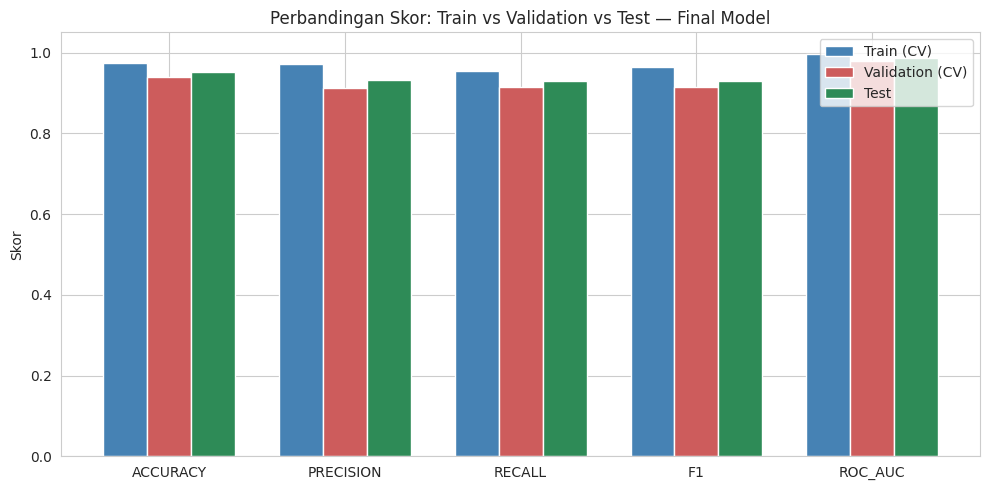

In [16]:
# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df["Train (CV)"], width, label="Train (CV)", color="steelblue")
ax.bar(x, comparison_df["Validation (CV)"], width, label="Validation (CV)", color="indianred")
ax.bar(x + width, comparison_df["Test"], width, label="Test", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Metric"])
ax.set_ylabel("Skor")
ax.set_title("Perbandingan Skor: Train vs Validation vs Test — Final Model")
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

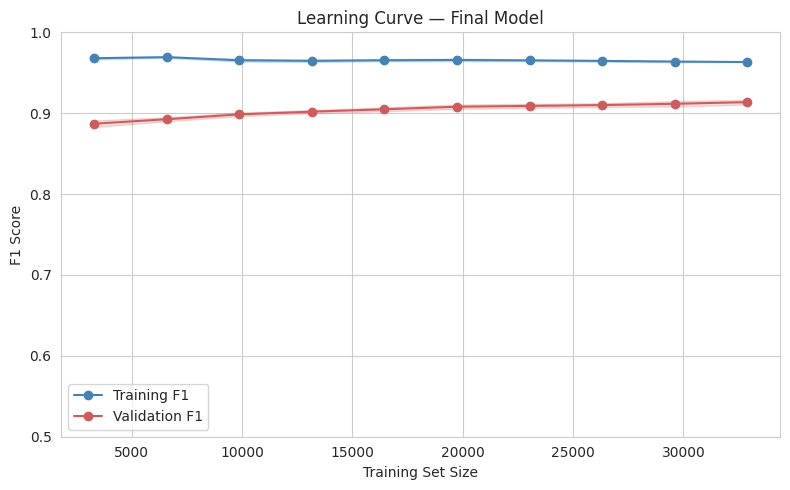

Interpretasi Learning Curve:
  - Gap Train vs Validation akhir: 0.0496 (<= 0.05) — overfitting terkendali.


In [17]:
# Learning Curve

train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores_lc, val_scores_lc = learning_curve(
    final_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=train_sizes,
    scoring="f1",
    n_jobs=-1,
)

train_mean_lc = train_scores_lc.mean(axis=1)
train_std_lc = train_scores_lc.std(axis=1)
val_mean_lc = val_scores_lc.mean(axis=1)
val_std_lc = val_scores_lc.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes_abs, train_mean_lc, "o-", color="steelblue", label="Training F1")
ax.fill_between(train_sizes_abs, train_mean_lc - train_std_lc,
                train_mean_lc + train_std_lc, alpha=0.2, color="steelblue")
ax.plot(train_sizes_abs, val_mean_lc, "o-", color="indianred", label="Validation F1")
ax.fill_between(train_sizes_abs, val_mean_lc - val_std_lc,
                val_mean_lc + val_std_lc, alpha=0.2, color="indianred")

ax.set_xlabel("Training Set Size")
ax.set_ylabel("F1 Score")
ax.set_title("Learning Curve — Final Model")
ax.legend()
ax.set_ylim(0.5, 1.0)
ax.grid(True)

plt.tight_layout()
plt.show()

print("Interpretasi Learning Curve:")
final_gap = train_mean_lc[-1] - val_mean_lc[-1]
if final_gap > 0.05:
    print(f"  - Gap Train vs Validation akhir: {final_gap:.4f} (> 0.05) — masih ada indikasi overfitting.")
    print(f"  - Saran: tambah data training, atau perkecil kompleksitas model (max_depth lebih kecil, min_samples_leaf lebih besar).")
else:
    print(f"  - Gap Train vs Validation akhir: {final_gap:.4f} (<= 0.05) — overfitting terkendali.")

if val_mean_lc[-1] - val_mean_lc[0] < 0.02:
    print("  - Kurva validasi relatif datar — menambah data mungkin tidak akan meningkatkan performa secara signifikan.")
elif val_mean_lc[-1] - val_mean_lc[0] > 0.05:
    print("  - Kurva validasi masih naik — menambah data training bisa meningkatkan performa lebih lanjut.")

Top 15 fitur paling penting:


,Importance
directory_length,0.149704
length_url,0.083535
file_length,0.082752
qty_asterisk_directory,0.076532
qty_hyphen_file,0.073151
qty_hyphen_directory,0.065502
qty_slash_url,0.052889
qty_at_directory,0.048860
qty_percent_directory,0.048449
qty_questionmark_directory,0.036740


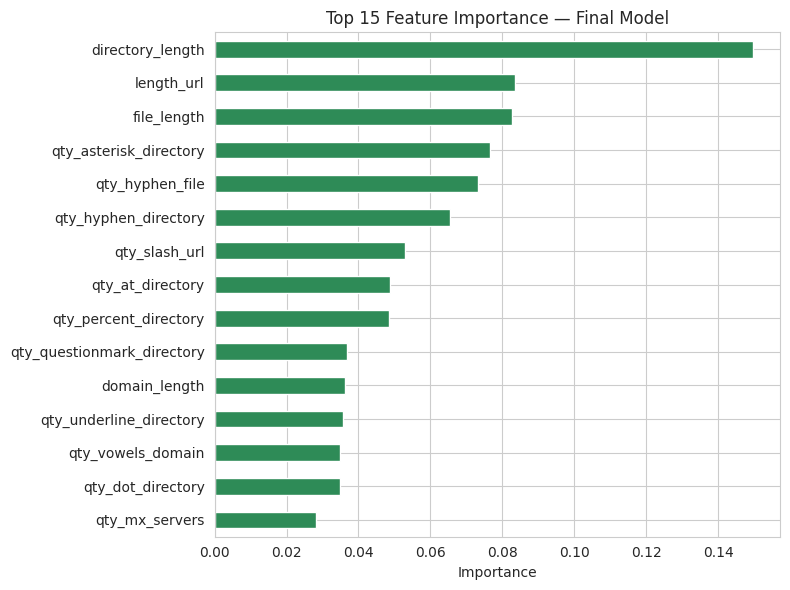

In [18]:
# Feature Importance
importance_series = pd.Series(
    final_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

print("Top 15 fitur paling penting:")
display(importance_series.head(15).to_frame("Importance"))

fig, ax = plt.subplots(figsize=(8, 6))
importance_series.head(15).sort_values().plot(
    kind="barh", color="seagreen", ax=ax
)
ax.set_title("Top 15 Feature Importance — Final Model")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [19]:
# Cumulative importance
cumulative = importance_series.cumsum()
n_features_90 = (cumulative < 0.90).sum() + 1
n_features_95 = (cumulative < 0.95).sum() + 1

print(f"Jumlah fitur untuk mencapai 90% kumulatif importance: {n_features_90}")
print(f"Jumlah fitur untuk mencapai 95% kumulatif importance: {n_features_95}")
print(f"\nTop 5 fitur menyumbang {cumulative.iloc[4]:.2%} dari total importance.")

Jumlah fitur untuk mencapai 90% kumulatif importance: 16
Jumlah fitur untuk mencapai 95% kumulatif importance: 19

Top 5 fitur menyumbang 46.57% dari total importance.


In [20]:
# Identifikasi error
results_df = test_df.copy()
results_df["predicted"] = y_pred
results_df["probability"] = y_prob
results_df["correct"] = (y_pred == y_test).astype(int)

false_positives = results_df[(results_df[TARGET_COL] == 0) & (results_df["predicted"] == 1)]
false_negatives = results_df[(results_df[TARGET_COL] == 1) & (results_df["predicted"] == 0)]

print(f"Total sampel test set: {len(results_df)}")
print(f"Benar: {results_df['correct'].sum()} ({results_df['correct'].mean():.2%})")
print(f"Salah: {(~results_df['correct'].astype(bool)).sum()} ({(~results_df['correct'].astype(bool)).mean():.2%})")
print(f"  False Positives (legitimate → phishing): {len(false_positives)}")
print(f"  False Negatives (phishing → legitimate): {len(false_negatives)}")

Total sampel test set: 17442
Benar: 16597 (95.16%)
Salah: 845 (4.84%)
  False Positives (legitimate → phishing): 419
  False Negatives (phishing → legitimate): 426


Perbandingan karakteristik: Correct vs Error

length_url:
  Correct - mean: 37.22, std: 57.38
  Error   - mean: 29.92, std: 18.36

domain_length:
  Correct - mean: 18.57, std: 6.47
  Error   - mean: 18.44, std: 6.19

qty_dot_url:
  Correct - mean: 2.21, std: 1.28
  Error   - mean: 2.00, std: 0.86

qty_hyphen_url:
  Correct - mean: 0.33, std: 1.11
  Error   - mean: 0.53, std: 1.47



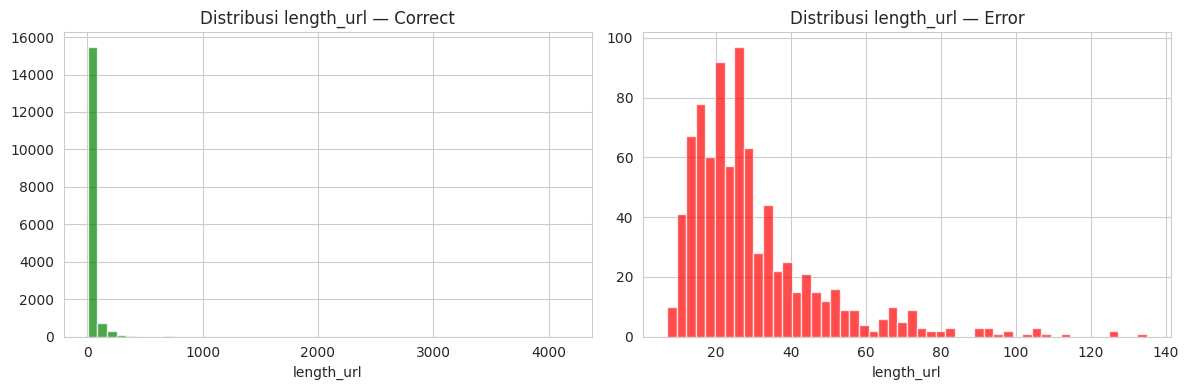

In [21]:
# Analisis karakteristik error

error_df = results_df[results_df["correct"] == 0]
correct_df = results_df[results_df["correct"] == 1]

print("Perbandingan karakteristik: Correct vs Error")
print()

key_features = ["length_url", "domain_length", "qty_dot_url", "qty_hyphen_url"]
available_features = [f for f in key_features if f in results_df.columns]

for feat in available_features:
    print(f"{feat}:")
    print(f"  Correct - mean: {correct_df[feat].mean():.2f}, std: {correct_df[feat].std():.2f}")
    print(f"  Error   - mean: {error_df[feat].mean():.2f}, std: {error_df[feat].std():.2f}")
    print()

if "length_url" in results_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(correct_df["length_url"], bins=50, alpha=0.7, color="green", label="Correct")
    axes[0].set_title("Distribusi length_url — Correct")
    axes[0].set_xlabel("length_url")

    axes[1].hist(error_df["length_url"], bins=50, alpha=0.7, color="red", label="Error")
    axes[1].set_title("Distribusi length_url — Error")
    axes[1].set_xlabel("length_url")

    plt.tight_layout()
    plt.show()

In [22]:
if len(false_positives) > 0:
    display(false_positives.sort_values("probability", ascending=False).head(10))
else:
    print("  (tidak ada)")

if len(false_negatives) > 0:
    display(false_negatives.sort_values("probability", ascending=True).head(10))
else:
    print("  (tidak ada)")

,directory_length,domain_length,email_in_url,file_length,length_url,params_length,qty_and_url,qty_asterisk_directory,qty_at_directory,qty_at_url,qty_dot_directory,qty_dot_domain,qty_dot_params,qty_dot_url,qty_equal_url,qty_hyphen_directory,qty_hyphen_domain,qty_hyphen_file,qty_hyphen_params,qty_hyphen_url,qty_mx_servers,qty_percent_directory,qty_percent_params,qty_questionmark_directory,qty_questionmark_params,qty_redirects,qty_slash_params,qty_slash_url,qty_tld_url,qty_underline_directory,qty_underline_params,qty_underline_url,qty_vowels_domain,phishing,predicted,probability,correct
9301,5,8,0,4,13,-1,0,0,0,0,0,1,-1,1,0,0,0,0,-1,0,1,0,-1,0,-1,1,-1,1,1,0,-1,0,2,0,1.0,0.996333,0
3077,6,16,0,5,22,-1,0,0,0,0,0,1,-1,1,0,0,0,0,-1,0,1,0,-1,0,-1,0,-1,1,1,0,-1,0,5,0,1.0,0.990667,0
13212,6,21,0,0,27,-1,0,0,0,0,0,1,-1,1,0,0,0,0,-1,0,1,0,-1,0,-1,0,-1,2,1,0,-1,0,8,0,1.0,0.985222,0
3289,21,19,0,9,40,-1,0,0,0,0,1,2,-1,3,0,0,0,0,-1,0,1,0,-1,0,-1,0,-1,4,1,0,-1,0,8,0,1.0,0.979357,0
8932,1,44,0,0,45,-1,0,0,0,0,0,2,-1,2,0,0,2,0,-1,2,0,0,-1,0,-1,1,-1,1,1,0,-1,0,15,0,1.0,0.976500,0
3402,1,39,0,0,40,-1,0,0,0,0,0,2,-1,2,0,0,0,0,-1,0,1,0,-1,0,-1,1,-1,1,1,0,-1,0,14,0,1.0,0.968722,0
11044,44,16,0,18,102,42,0,0,0,0,1,2,0,3,1,2,0,2,0,2,0,0,0,0,0,-1,0,4,1,0,0,0,4,0,1.0,0.966667,0
16762,15,22,0,9,37,-1,0,0,0,0,1,1,-1,2,0,0,0,0,-1,0,0,0,-1,0,-1,0,-1,2,1,0,-1,0,8,0,1.0,0.966000,0
13610,10,19,0,9,29,-1,0,0,0,0,1,1,-1,2,0,0,0,0,-1,0,5,0,-1,0,-1,0,-1,1,1,0,-1,0,6,0,1.0,0.964417,0
14825,17,17,0,0,34,-1,0,0,0,0,0,1,-1,1,0,0,0,0,-1,0,0,0,-1,0,-1,0,-1,3,1,0,-1,0,7,0,1.0,0.956667,0


,directory_length,domain_length,email_in_url,file_length,length_url,params_length,qty_and_url,qty_asterisk_directory,qty_at_directory,qty_at_url,qty_dot_directory,qty_dot_domain,qty_dot_params,qty_dot_url,qty_equal_url,qty_hyphen_directory,qty_hyphen_domain,qty_hyphen_file,qty_hyphen_params,qty_hyphen_url,qty_mx_servers,qty_percent_directory,qty_percent_params,qty_questionmark_directory,qty_questionmark_params,qty_redirects,qty_slash_params,qty_slash_url,qty_tld_url,qty_underline_directory,qty_underline_params,qty_underline_url,qty_vowels_domain,phishing,predicted,probability,correct
15871,-1,27,0,-1,27,-1,0,-1,-1,0,-1,2,-1,2,0,-1,0,-1,-1,0,1,-1,-1,-1,-1,0,-1,0,1,-1,-1,0,7,1,0.0,0.0,0
3153,-1,21,0,-1,21,-1,0,-1,-1,0,-1,3,-1,3,0,-1,1,-1,-1,1,2,-1,-1,-1,-1,0,-1,0,1,-1,-1,0,7,1,0.0,0.0,0
11518,-1,15,0,-1,15,-1,0,-1,-1,0,-1,1,-1,1,0,-1,0,-1,-1,0,1,-1,-1,-1,-1,1,-1,0,1,-1,-1,0,3,1,0.0,0.0,0
11399,-1,14,0,-1,14,-1,0,-1,-1,0,-1,2,-1,2,0,-1,0,-1,-1,0,1,-1,-1,-1,-1,0,-1,0,1,-1,-1,0,5,1,0.0,0.0,0
5627,-1,21,0,-1,21,-1,0,-1,-1,0,-1,3,-1,3,0,-1,0,-1,-1,0,1,-1,-1,-1,-1,1,-1,0,1,-1,-1,0,4,1,0.0,0.0,0
7790,-1,23,0,-1,23,-1,0,-1,-1,0,-1,2,-1,2,0,-1,1,-1,-1,1,3,-1,-1,-1,-1,0,-1,0,1,-1,-1,0,6,1,0.0,0.0,0
6521,-1,13,0,-1,13,-1,0,-1,-1,0,-1,1,-1,1,0,-1,0,-1,-1,0,1,-1,-1,-1,-1,1,-1,0,1,-1,-1,0,4,1,0.0,0.0,0
8814,-1,15,0,-1,15,-1,0,-1,-1,0,-1,1,-1,1,0,-1,0,-1,-1,0,1,-1,-1,-1,-1,1,-1,0,1,-1,-1,0,4,1,0.0,0.0,0
13739,-1,25,0,-1,25,-1,0,-1,-1,0,-1,2,-1,2,0,-1,0,-1,-1,0,1,-1,-1,-1,-1,1,-1,0,1,-1,-1,0,8,1,0.0,0.0,0
14276,-1,26,0,-1,26,-1,0,-1,-1,0,-1,2,-1,2,0,-1,0,-1,-1,0,0,-1,-1,-1,-1,0,-1,0,1,-1,-1,0,11,1,0.0,0.0,0


In [23]:
# Simpan model
joblib.dump(final_model, FINAL_MODEL_PATH)
print(f"Model disimpan: {FINAL_MODEL_PATH} ({joblib.os.path.getsize(FINAL_MODEL_PATH) / 1024 / 1024:.1f} MB)")

Model disimpan: model.pkl (37.7 MB)


In [24]:
feature_order = list(X_train.columns)

with open(FEATURE_ORDER_PATH, "w") as f:
    json.dump(feature_order, f, indent=2)

print(f"Feature order disimpan: {FEATURE_ORDER_PATH}")
print(f"Jumlah fitur: {len(feature_order)}")
print(f"Fitur: {feature_order}")

Feature order disimpan: feature_order.json
Jumlah fitur: 33
Fitur: ['directory_length', 'domain_length', 'email_in_url', 'file_length', 'length_url', 'params_length', 'qty_and_url', 'qty_asterisk_directory', 'qty_at_directory', 'qty_at_url', 'qty_dot_directory', 'qty_dot_domain', 'qty_dot_params', 'qty_dot_url', 'qty_equal_url', 'qty_hyphen_directory', 'qty_hyphen_domain', 'qty_hyphen_file', 'qty_hyphen_params', 'qty_hyphen_url', 'qty_mx_servers', 'qty_percent_directory', 'qty_percent_params', 'qty_questionmark_directory', 'qty_questionmark_params', 'qty_redirects', 'qty_slash_params', 'qty_slash_url', 'qty_tld_url', 'qty_underline_directory', 'qty_underline_params', 'qty_underline_url', 'qty_vowels_domain']


In [25]:
selected_features = {
    "n_features": len(feature_order),
    "features": feature_order,
    "target_column": TARGET_COL,
    "model_type": "RandomForestClassifier",
    "best_params": best_params,
    "test_metrics": {
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "roc_auc": round(roc_auc, 4),
    },
    "top_features": importance_series.head(10).to_dict(),
}

with open(SELECTED_FEATURES_PATH, "w") as f:
    json.dump(selected_features, f, indent=2)

print(f"Selected features disimpan: {SELECTED_FEATURES_PATH}")

Selected features disimpan: selected_features.json
